
--- Training MLP ---
Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8277 - loss: 0.4121 - val_accuracy: 0.8889 - val_loss: 0.2924
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9003 - loss: 0.2532 - val_accuracy: 0.9204 - val_loss: 0.2105
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9179 - loss: 0.2081 - val_accuracy: 0.9278 - val_loss: 0.1885
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9215 - loss: 0.1979 - val_accuracy: 0.9300 - val_loss: 0.1836
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9224 - loss: 0.1949 - val_accuracy: 0.9312 - val_loss: 0.1809
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9235 - loss: 0.1935 - val_accuracy: 0.9312 - val_loss: 0.1791
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9239 - loss: 0.1926 - val_accuracy: 0.9309 - val_loss: 0.1780
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9239 - loss: 0.1

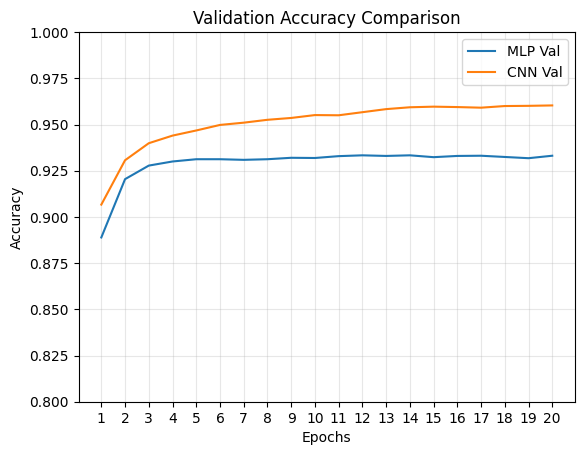

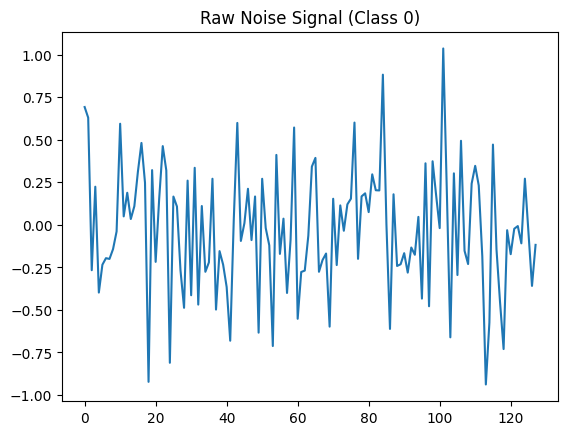

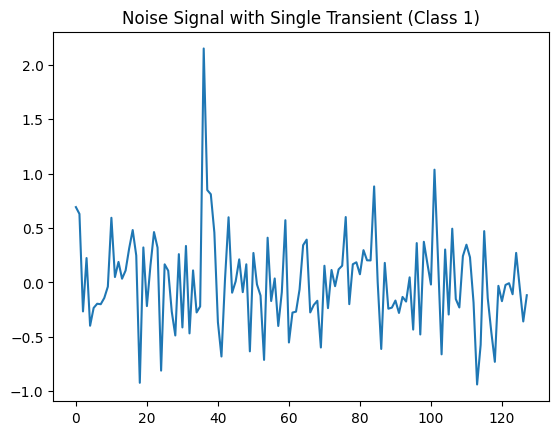

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# =========================================================
# 1. Base signal generation (paired noise)
# =========================================================
def generate_base_signals(N, n=128):
    signals = []
    for _ in range(N):
        noise_std = np.random.uniform(0.22, 0.40)
        base = np.random.normal(0, noise_std, n)
        signals.append(base)
    return np.array(signals)


def add_transient(x):
    x = x.copy()

    pos = np.random.randint(20, 110)
    amp = np.random.uniform(0.9, 2.2)

    if np.random.rand() < 0.10:
        amp *= 0.75

    width = np.random.randint(3, 7)
    shape = np.exp(-np.linspace(0, 1.0, width))

    x[pos:pos+width] += amp * shape
    return x


# =========================================================
# 2. Haar wavelet
# =========================================================
def haar_dwt(x):
    A1 = (x[0::2] + x[1::2]) / 2.0
    D1 = (x[0::2] - x[1::2]) / 2.0

    A2 = (A1[0::2] + A1[1::2]) / 2.0
    D2 = (A1[0::2] - A1[1::2]) / 2.0

    return A1, D1, A2, D2


def extract_features(x):
    A1, D1, A2, D2 = haar_dwt(x)

    def stats(b):
        return [
            np.mean(b),
            np.std(b),
            np.max(np.abs(b)),
            np.sum(b * b)
        ]

    feats = []
    for b in [A1, D1, A2, D2]:
        feats.extend(stats(b))

    return np.array(feats, dtype=np.float32)


# =========================================================
# 3. Dataset
# =========================================================
N = 30000
base_signals = generate_base_signals(N)

X_feat = []
X_raw = []
y = []

for base in base_signals:
    sig0 = base
    sig1 = add_transient(base)

    X_feat.append(extract_features(sig0))
    X_raw.append(sig0)
    y.append(0)

    X_feat.append(extract_features(sig1))
    X_raw.append(sig1)
    y.append(1)

X_feat = np.array(X_feat)
X_raw = np.array(X_raw)
y = np.array(y)

X_raw = X_raw[..., np.newaxis]


# =========================================================
# 4. Train / Val / Test split
# =========================================================
Xf_train, Xf_temp, Xr_train, Xr_temp, y_train, y_temp = train_test_split(
    X_feat, X_raw, y, test_size=0.3, random_state=42
)

Xf_val, Xf_test, Xr_val, Xr_test, y_val, y_test = train_test_split(
    Xf_temp, Xr_temp, y_temp, test_size=0.5, random_state=42
)


# =========================================================
# 5. MLP
# =========================================================
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(16,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])


# =========================================================
# 6. CNN
# =========================================================
cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 1)),
    tf.keras.layers.Conv1D(8, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(16, 5, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])


# =========================================================
# 7. Train
# =========================================================
print("\n--- Training MLP ---")
hist_mlp = mlp.fit(
    Xf_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(Xf_val, y_val),
    verbose=1
)

print("\n--- Training CNN ---")
hist_cnn = cnn.fit(
    Xr_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(Xr_val, y_val),
    verbose=1
)


# =========================================================
# 8. Evaluate
# =========================================================
mlp_loss, mlp_acc = mlp.evaluate(Xf_test, y_test, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(Xr_test, y_test, verbose=0)

print("\nFINAL RESULTS")
print("---------------------")
print("MLP :", mlp_acc)
print("CNN :", cnn_acc)


# =========================================================
# 9. FIXED accuracy plot (0.8 → 1.0, integer epochs)
# =========================================================
epochs = np.arange(1, len(hist_mlp.history['val_accuracy']) + 1)

plt.figure()
plt.plot(epochs, hist_mlp.history['val_accuracy'], label='MLP Val')
plt.plot(epochs, hist_cnn.history['val_accuracy'], label='CNN Val')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.ylim(0.8, 1.0)   # <-- UPDATED RANGE
plt.xticks(epochs)   # integers only

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================================
# 10. Waveform Plot 1 — Raw Noise
# =========================================================
idx = np.random.randint(0, len(Xr_test))
clean = Xr_test[idx].squeeze()

plt.figure()
plt.plot(clean)
plt.title("Raw Noise Signal (Class 0)")
plt.show()


# =========================================================
# 11. Waveform Plot 2 — Noise + Transient
# =========================================================
noisy = add_transient(clean)

plt.figure()
plt.plot(noisy)
plt.title("Noise Signal with Single Transient (Class 1)")
plt.show()